2. Implement a simple Generative Adversarial Network for image generation using 
Tensorflow/PyTorch. 

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


GPU Available: True
cuda


In [ ]:
# !pip install torch torchvision matplotlib


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os


In [3]:
print("Hello")

Hello


In [ ]:
# import os

# for dirname, _, filenames in os.walk('/kaggle/input'):
#     print(dirname)


In [4]:
data_path = "/kaggle/input/cartoon-faces-googles-cartoon-set/cartoonset100k_jpg"

image_size = 64
batch_size = 64

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.ImageFolder(root=data_path, transform=transform)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Dataset Loaded:", len(dataset))


Dataset Loaded: 100000


In [5]:
nz = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)


In [7]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
beta1 = 0.5

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

os.makedirs("generated", exist_ok=True)


In [8]:
num_epochs = 20

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(dataloader):

        # ---- Train Discriminator ----
        netD.zero_grad()

        real_images = images.to(device)
        batch = real_images.size(0)

        labels = torch.ones(batch, device=device)
        output = netD(real_images)
        lossD_real = criterion(output, labels)

        noise = torch.randn(batch, nz, 1, 1, device=device)
        fake_images = netG(noise)

        labels = torch.zeros(batch, device=device)
        output = netD(fake_images.detach())
        lossD_fake = criterion(output, labels)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # ---- Train Generator ----
        netG.zero_grad()

        labels = torch.ones(batch, device=device)
        output = netD(fake_images)

        lossG = criterion(output, labels)
        lossG.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Step [{i}/{len(dataloader)}] "
                  f"Loss D: {lossD.item():.4f}, Loss G: {lossG.item():.4f}")

    # Save sample images
    with torch.no_grad():
        fake = netG(fixed_noise)
        save_image(fake, f"generated/epoch_{epoch+1}.png", normalize=True)

print("Training Finished!")


Epoch [1/20] Step [0/1563] Loss D: 1.6955, Loss G: 1.5013
Epoch [1/20] Step [100/1563] Loss D: 0.7255, Loss G: 2.8668
Epoch [1/20] Step [200/1563] Loss D: 0.5513, Loss G: 4.3496
Epoch [1/20] Step [300/1563] Loss D: 0.4786, Loss G: 2.5105
Epoch [1/20] Step [400/1563] Loss D: 0.5172, Loss G: 1.9191
Epoch [1/20] Step [500/1563] Loss D: 0.5491, Loss G: 5.0678
Epoch [1/20] Step [600/1563] Loss D: 0.4570, Loss G: 3.8977
Epoch [1/20] Step [700/1563] Loss D: 0.5722, Loss G: 2.0850
Epoch [1/20] Step [800/1563] Loss D: 0.3159, Loss G: 4.0950
Epoch [1/20] Step [900/1563] Loss D: 0.3106, Loss G: 1.8326
Epoch [1/20] Step [1000/1563] Loss D: 0.1249, Loss G: 3.3911
Epoch [1/20] Step [1100/1563] Loss D: 0.3168, Loss G: 5.7379
Epoch [1/20] Step [1200/1563] Loss D: 0.1699, Loss G: 3.8923
Epoch [1/20] Step [1300/1563] Loss D: 0.1362, Loss G: 3.7470
Epoch [1/20] Step [1400/1563] Loss D: 0.0812, Loss G: 4.8011
Epoch [1/20] Step [1500/1563] Loss D: 0.0387, Loss G: 5.4846
Epoch [2/20] Step [0/1563] Loss D: 0

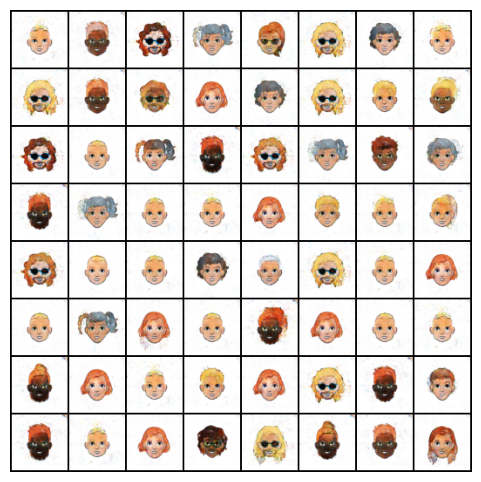

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("generated/epoch_20.png")
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()


In [10]:
torch.save(netG.state_dict(), "generator.pth")
torch.save(netD.state_dict(), "discriminator.pth")
